In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('data.csv')
df['success_val'] = df['is_success'].map({'yes': 1, 'no': 0})
summary = df.groupby(['test_type', 'distance (cm)']).agg(
    total_tests=('is_success', 'count'),
    success_count=('success_val', 'sum'),
    avg_time_sec=('time (s)', 'mean')
).reset_index()
summary['success_rate (%)'] = (summary['success_count'] / summary['total_tests']) * 100
summary.index = summary.index + 1
print("โหลดและเตรียมข้อมูลเรียบร้อย!")

โหลดและเตรียมข้อมูลเรียบร้อย!


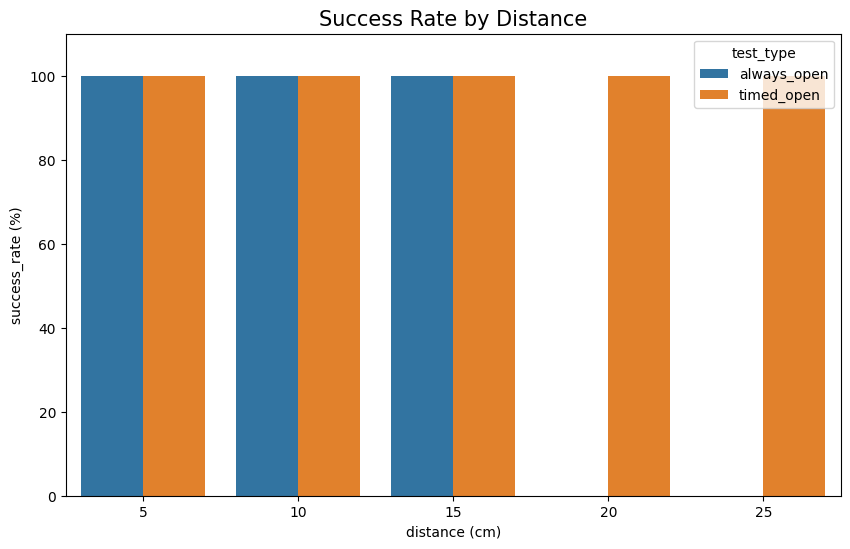

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(data=summary, x='distance (cm)', y='success_rate (%)', hue='test_type')
plt.title('Success Rate by Distance', fontsize=15)
plt.ylim(0, 110)
plt.show()

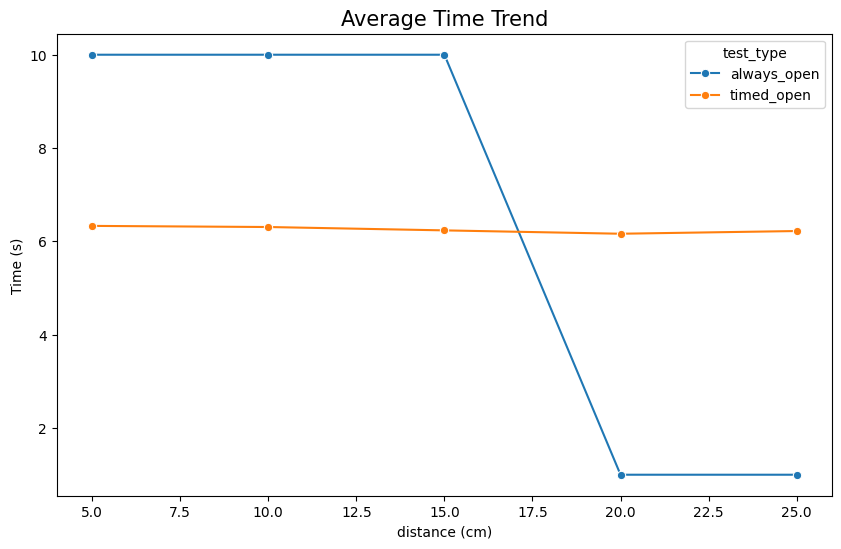

In [10]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=summary, x='distance (cm)', y='avg_time_sec', hue='test_type', marker='o')
plt.title('Average Time Trend', fontsize=15)
plt.ylabel('Time (s)')
plt.show()

In [8]:
styled_summary = summary.style \
    .background_gradient(subset=['success_rate (%)'], cmap='RdYlGn') \
    .background_gradient(subset=['avg_time_sec'], cmap='Blues_r') \
    .format({
        'success_rate (%)': '{:.2f}%', 
        'avg_time_sec': '{:.2f} s'
    }) \
    .set_caption("Experiment Summary: Categorized by Test Type and Distance") \
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#333'), ('color', 'white'), ('font-family', 'sans-serif')]
    }])
display(styled_summary)

,test_type,distance (cm),total_tests,success_count,avg_time_sec,success_rate (%)
1,always_open,5,5,5,10.00 s,100.00%
2,always_open,10,5,5,10.00 s,100.00%
3,always_open,15,5,5,10.00 s,100.00%
4,always_open,20,5,0,1.00 s,0.00%
5,always_open,25,5,0,1.00 s,0.00%
6,timed_open,5,5,5,6.33 s,100.00%
7,timed_open,10,5,5,6.31 s,100.00%
8,timed_open,15,5,5,6.24 s,100.00%
9,timed_open,20,5,5,6.16 s,100.00%
10,timed_open,25,5,5,6.22 s,100.00%
